## Setup & Imports

In [1]:
# ==========================================
# Blockchain Supply Chain ML Project
# Compliance Check Prediction
# ==========================================

!pip install lightgbm
!pip install lightgbm catboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})
PALETTE = "husl"

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, ExtraTreesClassifier)
# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics — classification
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
# Metrics — regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Advanced boosting
import xgboost as xgb
import lightgbm as lgb

print("All libraries loaded ✅")
print(f"XGBoost {xgb.__version__} | LightGBM {lgb.__version__}")

Defaulting to user installation because normal site-packages is not writeable
All libraries loaded ✅
XGBoost 3.2.0 | LightGBM 4.6.0


## Data Loading & Overview

In [2]:
df = pd.read_csv('DataCoSupplyChainDataset.csv',encoding = 'Latin-1')

In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (180519, 53)


In [4]:
# Display first 5 rows
df.head()

,Type,Days for shipment (scheduled),Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,...,Shipping Mode,order_year,order_month,order_day,order_date,order_dayofweek,order_hour,order_quarter,discount_rate,price_band
0,DEBIT,4,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,...,Standard Class,2018,1,31,2018-01-31 22:56:00,2,22,1,0.041667,3
1,TRANSFER,4,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,...,Standard Class,2018,1,13,2018-01-13 12:27:00,5,12,1,0.052640,3
2,CASH,4,0,73,Sporting Goods,San Jose,EE. UU.,Gillian,19491,Maldonado,...,Standard Class,2018,1,13,2018-01-13 12:06:00,5,12,1,0.058214,3
3,DEBIT,4,0,73,Sporting Goods,Los Angeles,EE. UU.,Tana,19490,Tate,...,Standard Class,2018,1,13,2018-01-13 11:45:00,5,11,1,0.075260,3
4,PAYMENT,4,0,73,Sporting Goods,Caguas,Puerto Rico,Orli,19489,Hendricks,...,Standard Class,2018,1,13,2018-01-13 11:24:00,5,11,1,0.098910,3


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Late_delivery_risk             180519 non-null  int64  
 3   Category Id                    180519 non-null  int64  
 4   Category Name                  180519 non-null  object 
 5   Customer City                  180519 non-null  object 
 6   Customer Country               180519 non-null  object 
 7   Customer Fname                 180519 non-null  object 
 8   Customer Id                    180519 non-null  int64  
 9   Customer Lname                 180519 non-null  object 
 10  Customer Segment               180519 non-null  object 
 11  Customer State                 180519 non-null  object 
 12  Customer Street               

In [6]:
# Missing values
df.isnull().sum()

Type                             0
Days for shipment (scheduled)    0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrders)          0
Order Id                         0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
Order Item Product P

In [7]:
# Remove duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# Statistical summary
df.describe()

,Days for shipment (scheduled),Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,...,Product Price,Product Status,order_year,order_month,order_day,order_dayofweek,order_hour,order_quarter,discount_rate,price_band
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.0,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,2.931847,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,...,141.232550,0.0,2015.971150,6.235449,15.739346,3.007622,11.483689,2.417319,0.119990,1.345736
std,1.374449,0.497664,15.640064,4162.918106,37542.149165,1.629246,9.813646,21.433241,4162.918106,21045.379569,...,139.732492,0.0,0.829429,3.403571,8.821895,2.001536,6.923006,1.096876,0.091336,1.160456
min,0.000000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,...,9.990000,0.0,2015.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,...,50.000000,0.0,2015.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.041670,0.000000
50%,4.000000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,...,59.990002,0.0,2016.000000,6.000000,16.000000,3.000000,11.000000,2.000000,0.110683,1.000000
75%,4.000000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,...,199.990005,0.0,2017.000000,9.000000,23.000000,5.000000,17.000000,3.000000,0.190488,2.000000
max,4.000000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,...,1999.989990,0.0,2018.000000,12.000000,31.000000,6.000000,23.000000,4.000000,0.333778,3.000000


In [9]:
# Column names
print(df.columns)

Index(['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk',
       'Category Id', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'order_year', 'order_month', 'order_day', 'order_date',
       'or

# Data Cleaning

In [10]:
# Fill missing values in numerical columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values after cleaning
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Type                             0
Days for shipment (scheduled)    0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrders)          0
Order Id                         0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id           

In [11]:
# ── Columns to DROP (post-fulfillment / leakage risk) ────────────────────
LEAKAGE_COLS = [
    # Direct outcome columns
    'Days for shipping (real)',   # actual delivery time — only known after delivery
    'Delivery Status',            # directly encodes Late_delivery_risk
    'Benefit per order',          # financial outcome — known after order settlement
    'Sales per customer',         # aggregated post-sale metric

    # High-cardinality ID / URL columns (no predictive value)
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Order Zipcode',              # very sparse
]

# ── Target columns (exclude from features) ────────────────────────────────
CLF_TARGET = 'Late_delivery_risk'   # binary: 0 / 1
REG_TARGET  = 'Order Profit Per Order'

print("Columns in dataset:")
print(df.columns.tolist())
print(f"\nDropping leakage / irrelevant columns: {LEAKAGE_COLS}")

Columns in dataset:
['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode', 'order_year', 'order_month', 'order_day', 'order_date', 'order_dayofweek', 'order_hour', 'order_quarter', 'discount_rate', 'price_band']

Dropp

In [12]:
# ── Build clean dataframe ─────────────────────────────────────────────────
cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df = df.drop(columns=cols_to_drop).copy()

# Also drop the reg target from classification features and vice versa
print(f"Shape after dropping leakage cols: {df.shape}")
print(f"\nClass balance (Late_delivery_risk):")
print(df[CLF_TARGET].value_counts(normalize=True).rename({0: 'On time', 1: 'Late'}))

Shape after dropping leakage cols: (180519, 53)

Class balance (Late_delivery_risk):
Late_delivery_risk
Late       0.548291
On time    0.451709
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

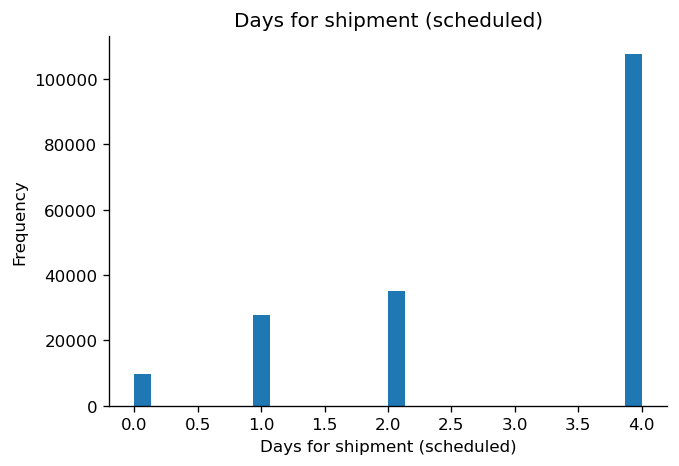

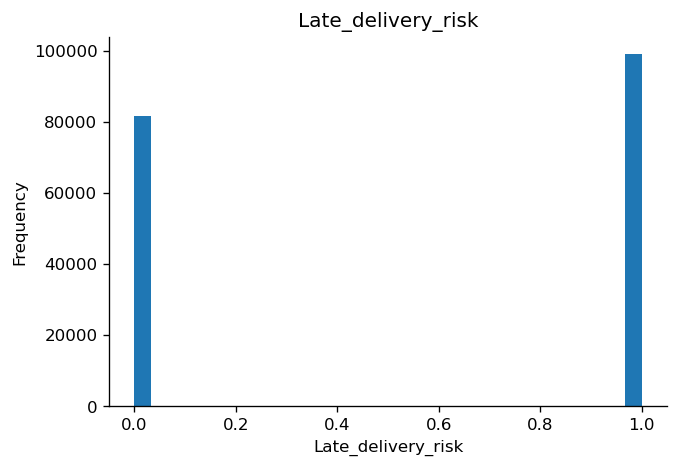

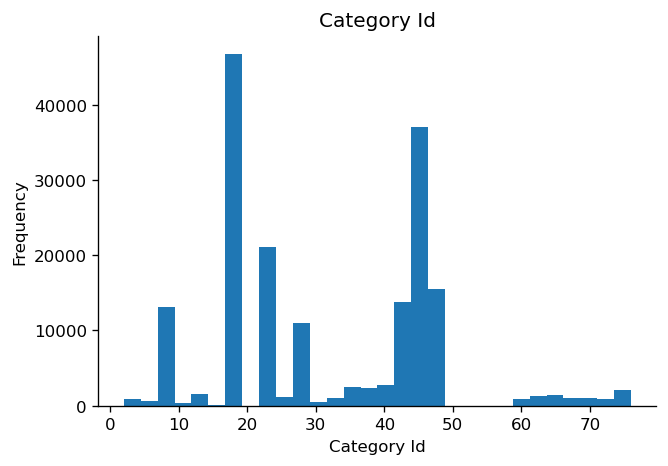

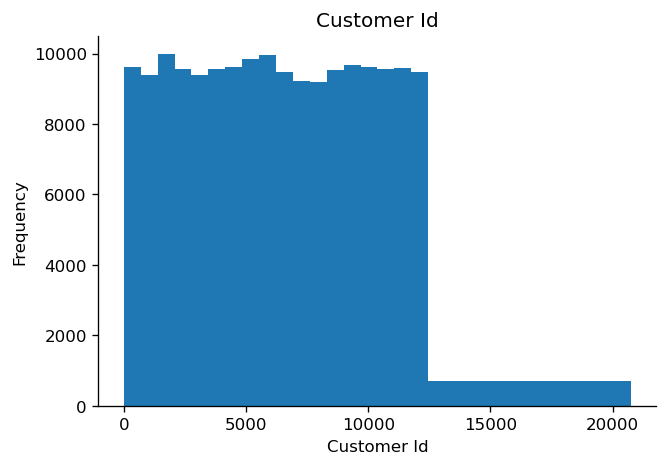

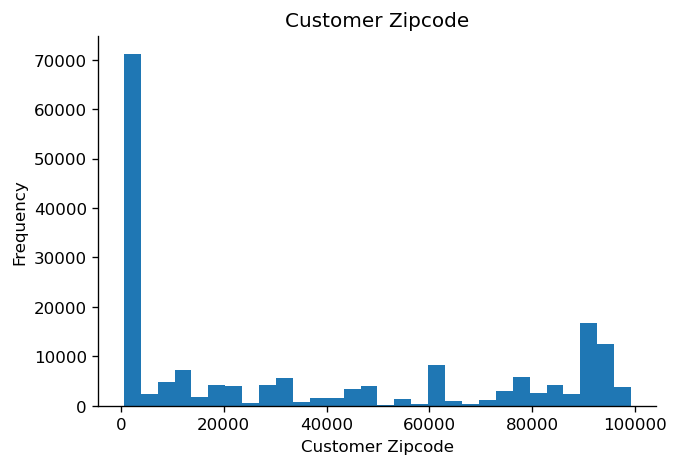

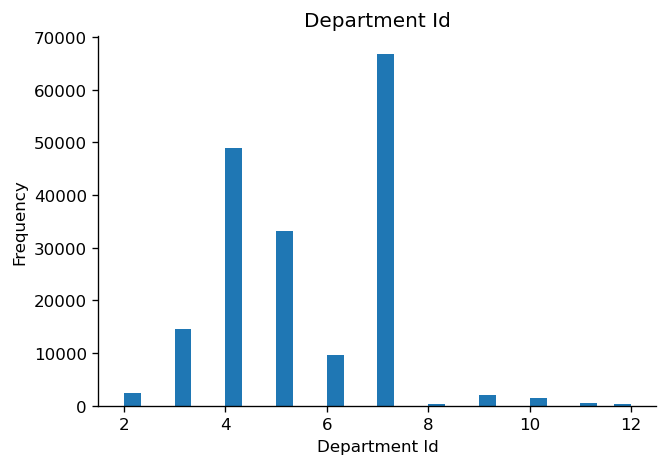

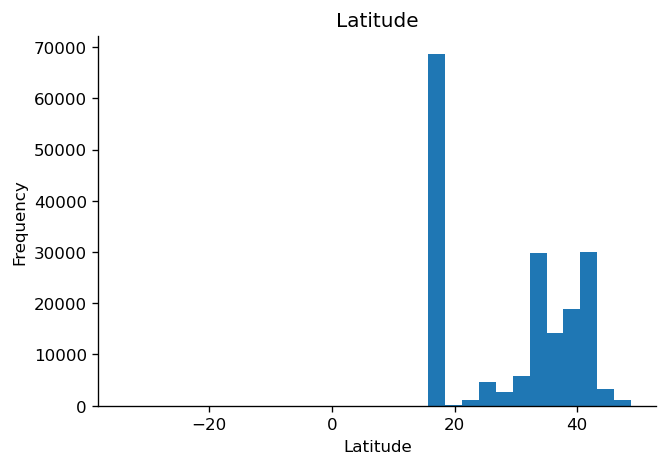

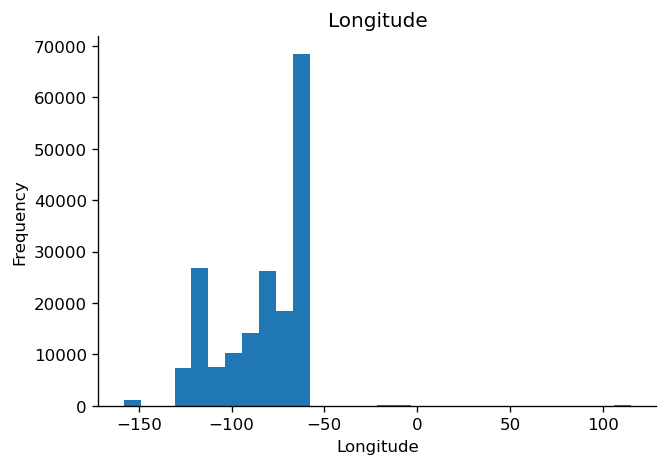

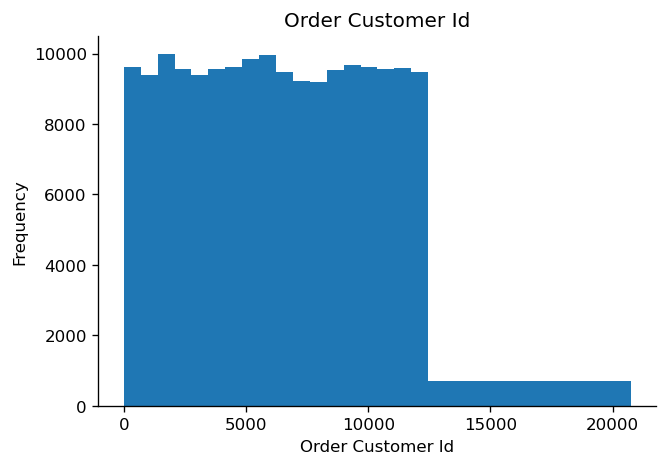

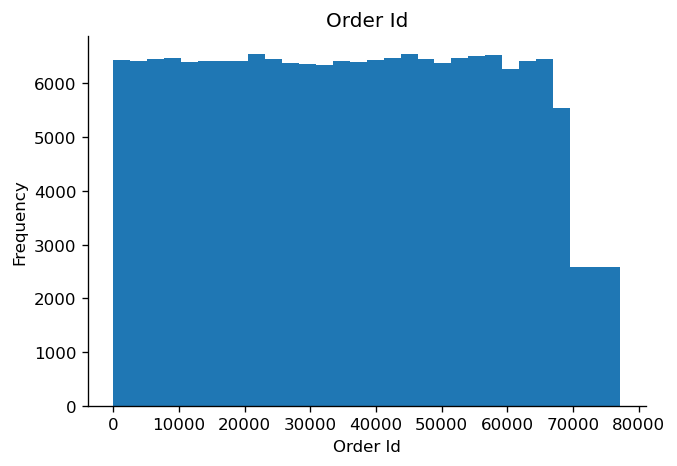

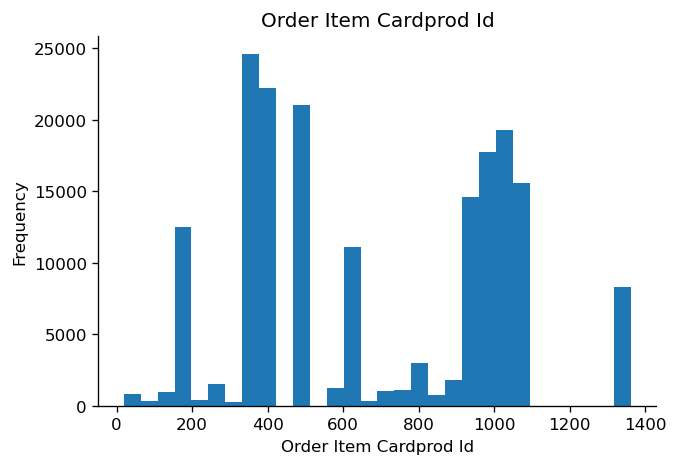

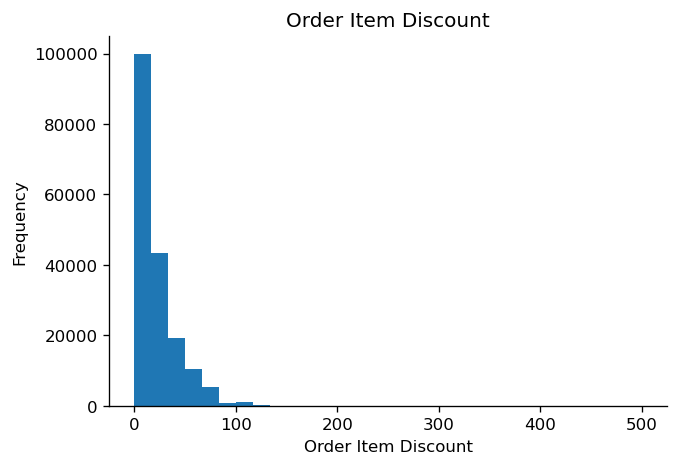

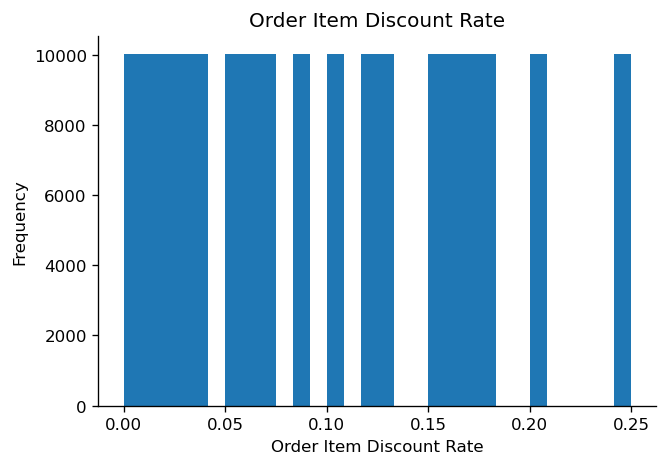

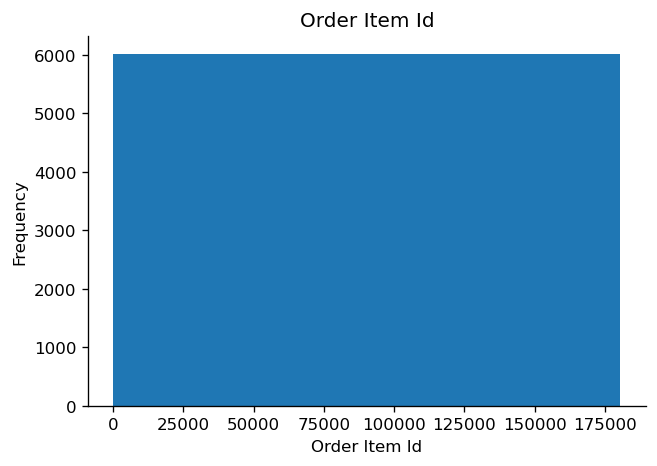

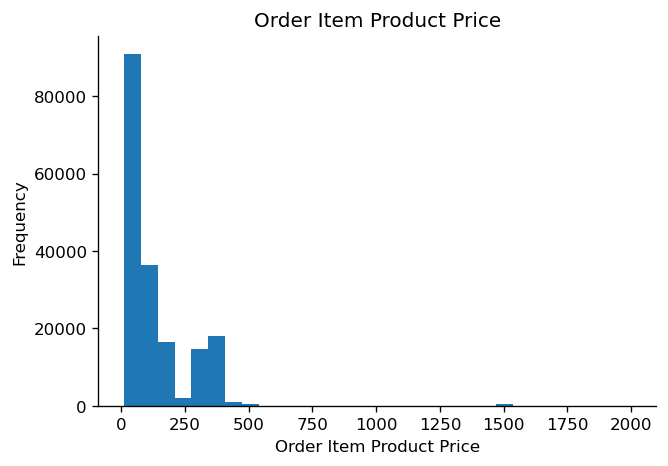

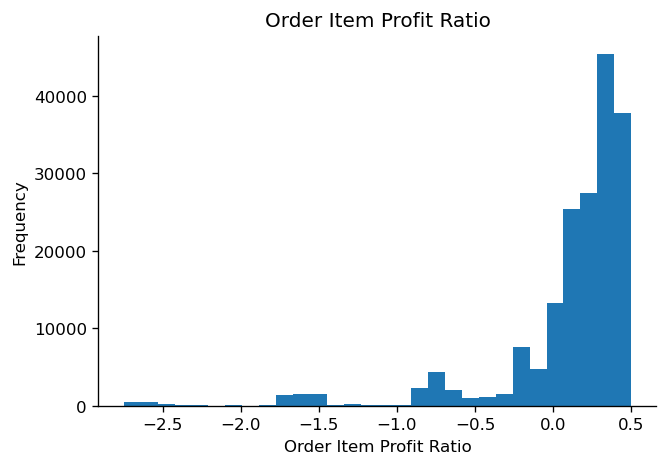

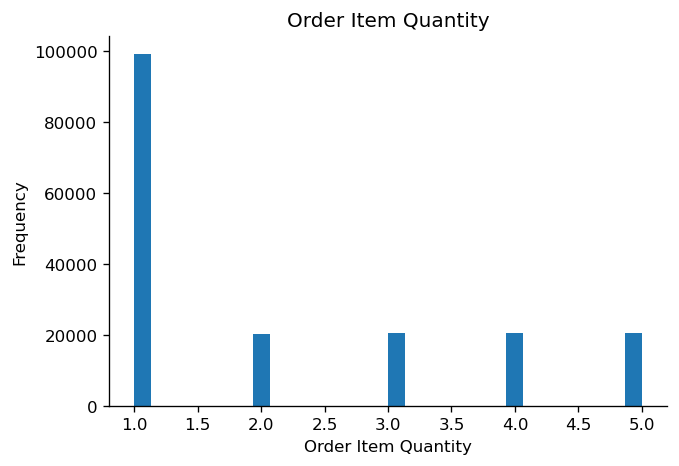

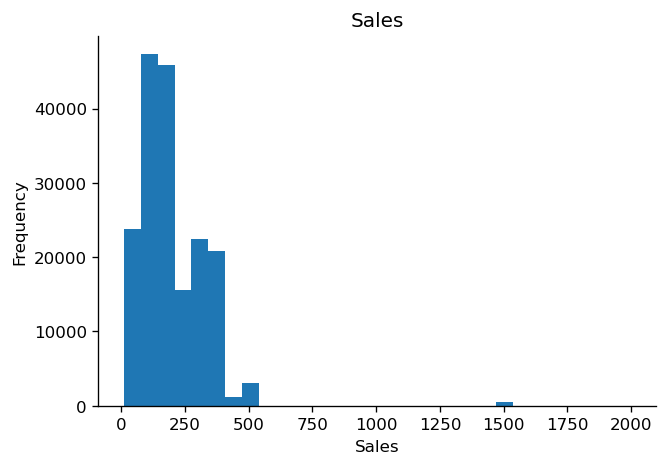

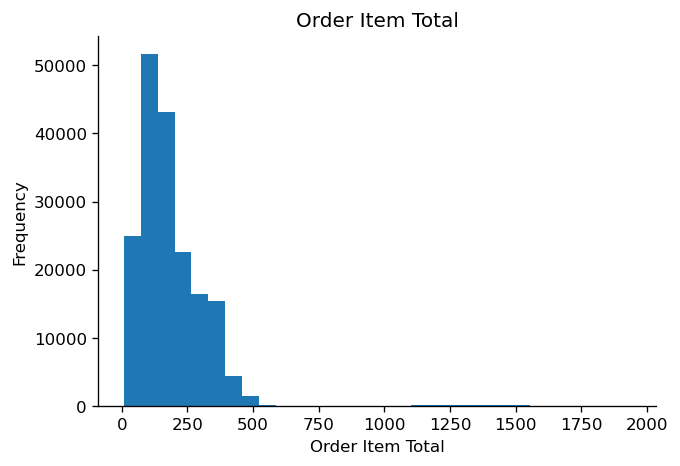

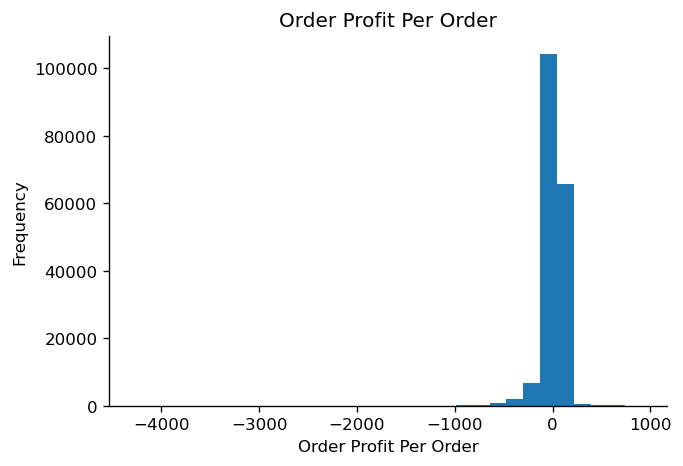

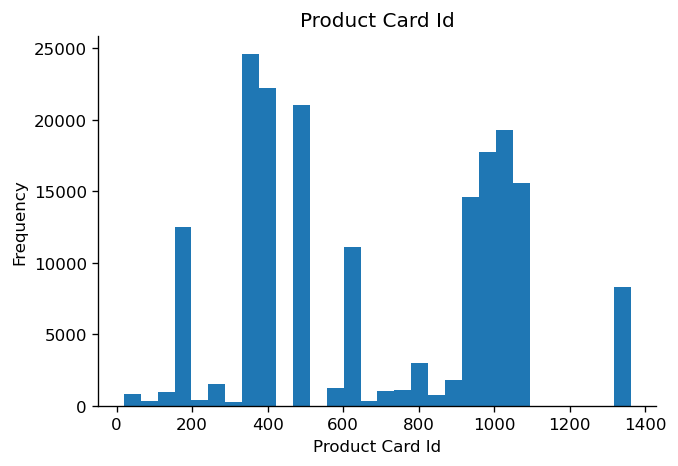

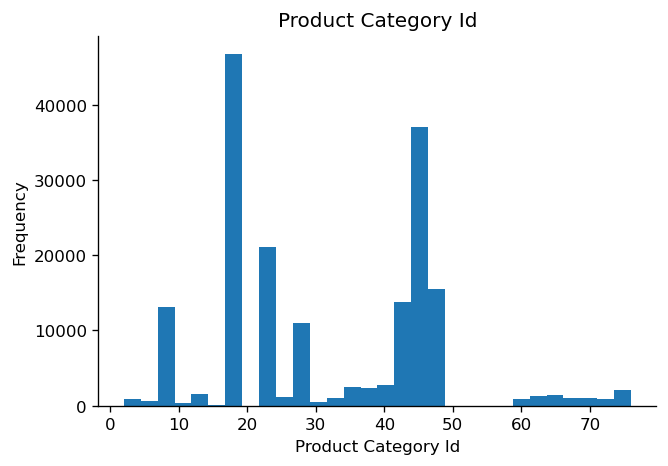

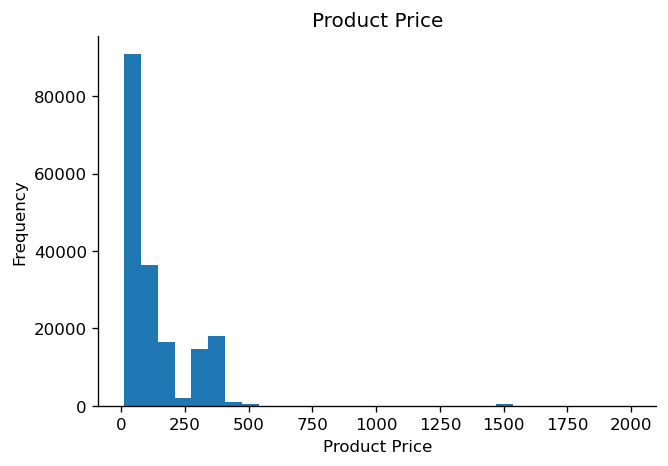

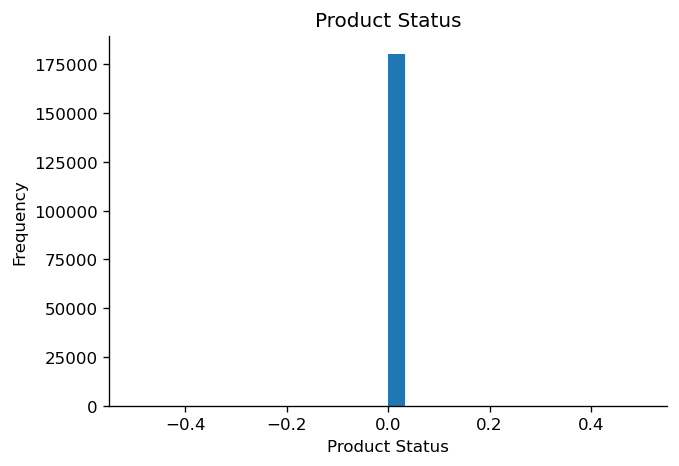

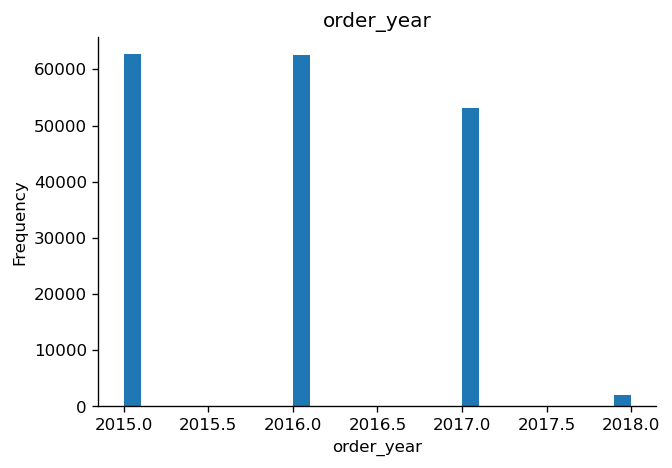

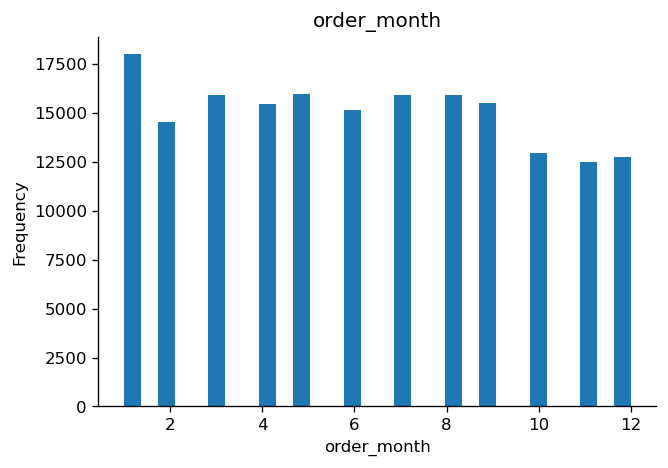

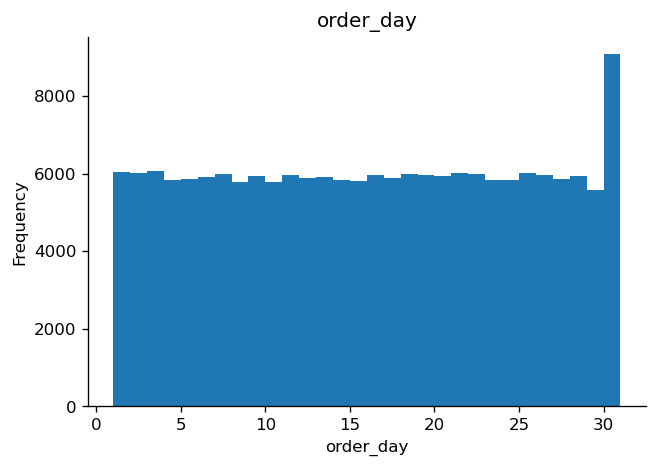

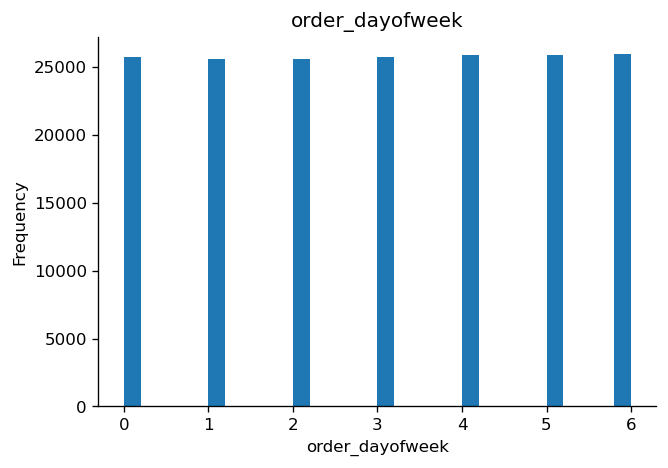

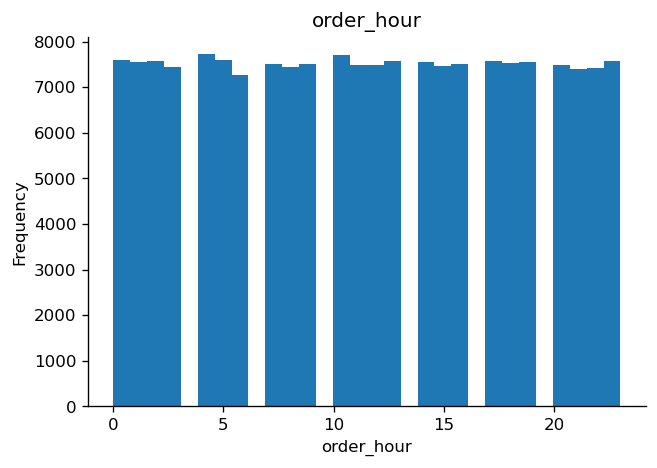

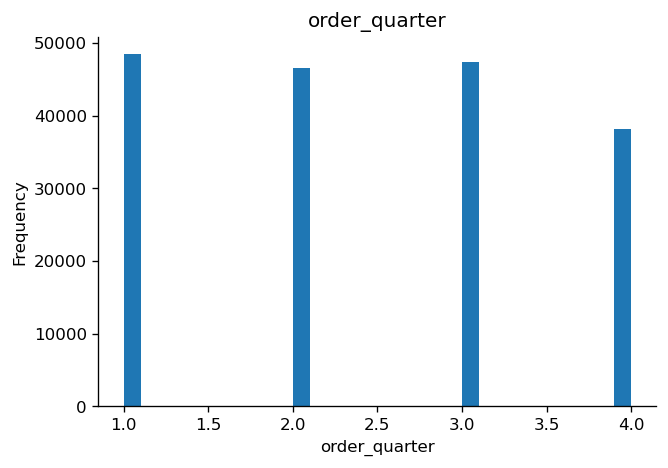

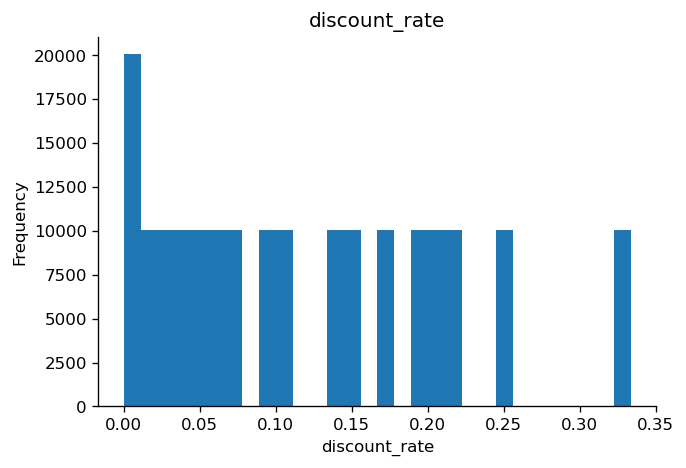

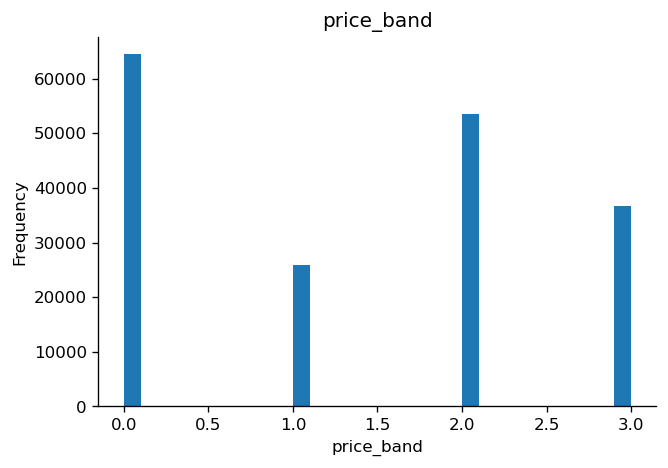

In [13]:
# Numerical Distribution
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Correlation Heatmap

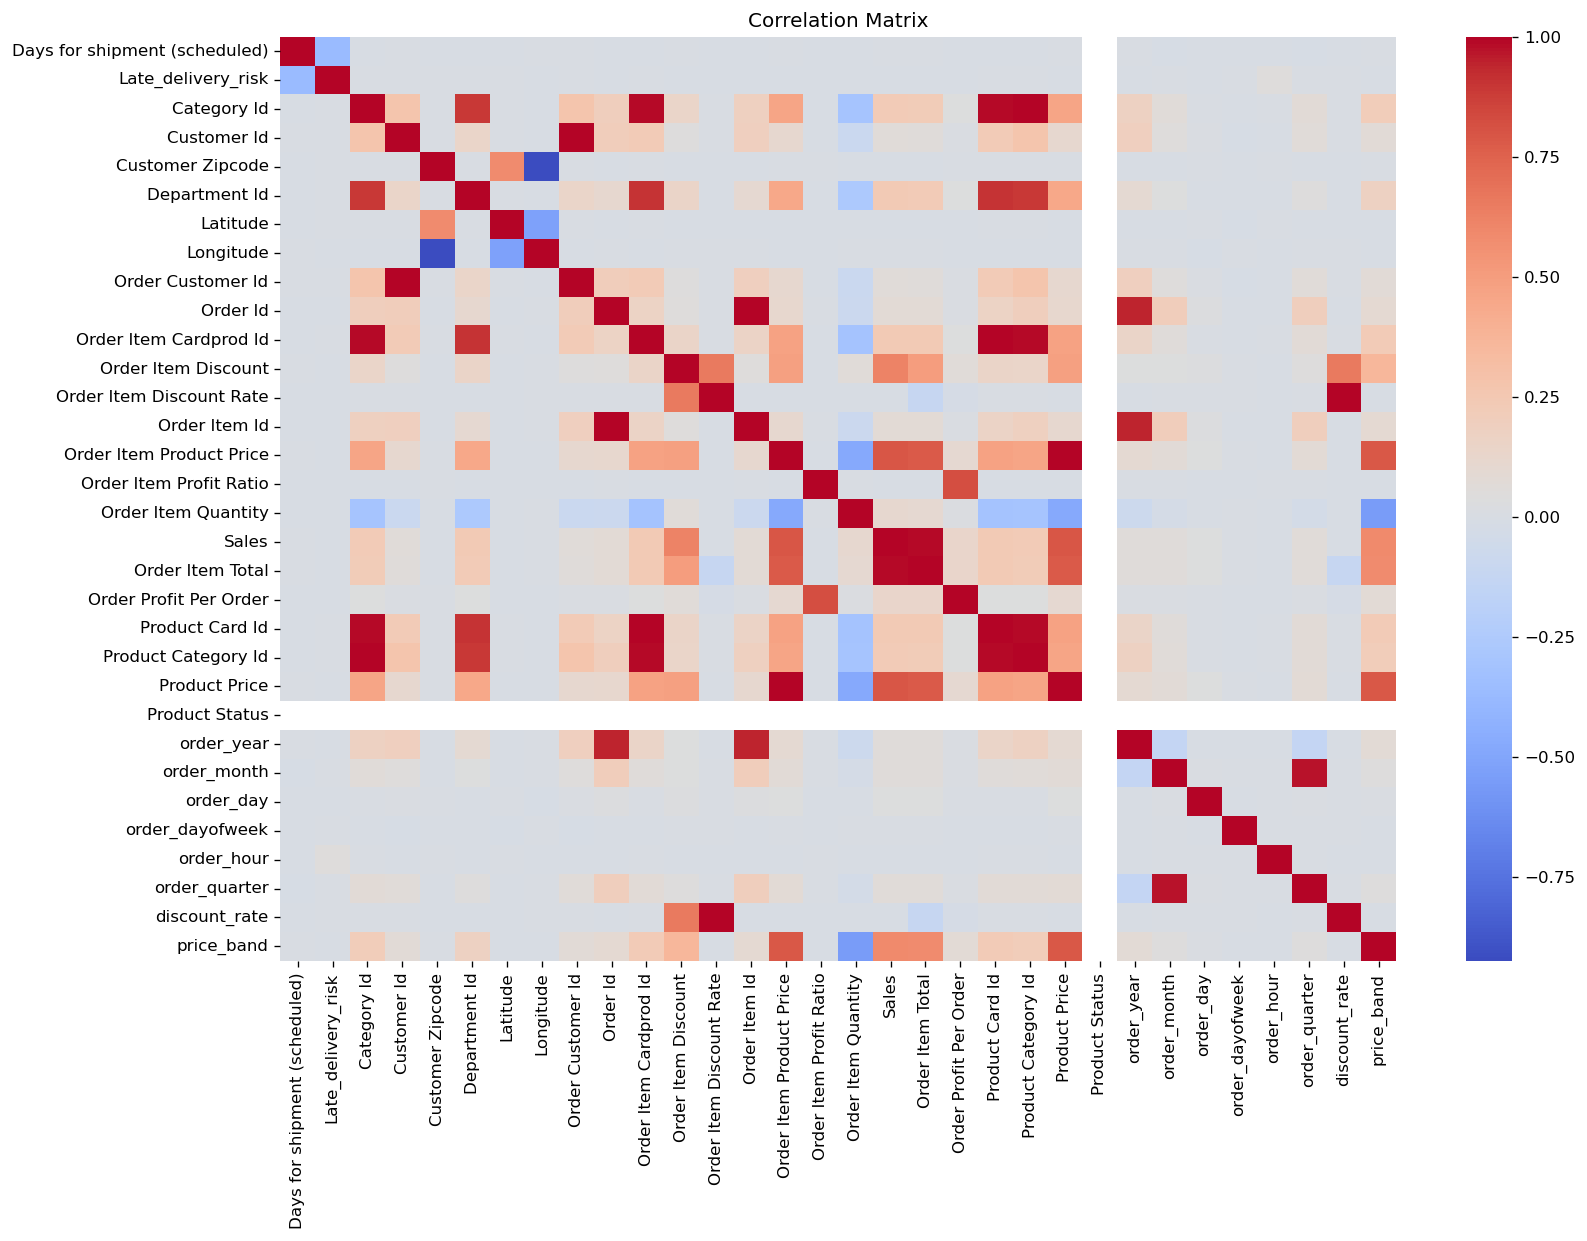

In [14]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [15]:
# Missing values analysis

missing = df.isnull().sum()

# Keep only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values per column:")
print(missing)

if len(missing) > 0:
    plt.figure(figsize=(8, max(3, len(missing) * 0.4)))

    missing.plot(
        kind='barh'
    )

    plt.title("Missing Values per Column")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Columns")

    plt.tight_layout()
    plt.show()

else:
    print("No missing values!")

Missing values per column:
Series([], dtype: int64)
No missing values!


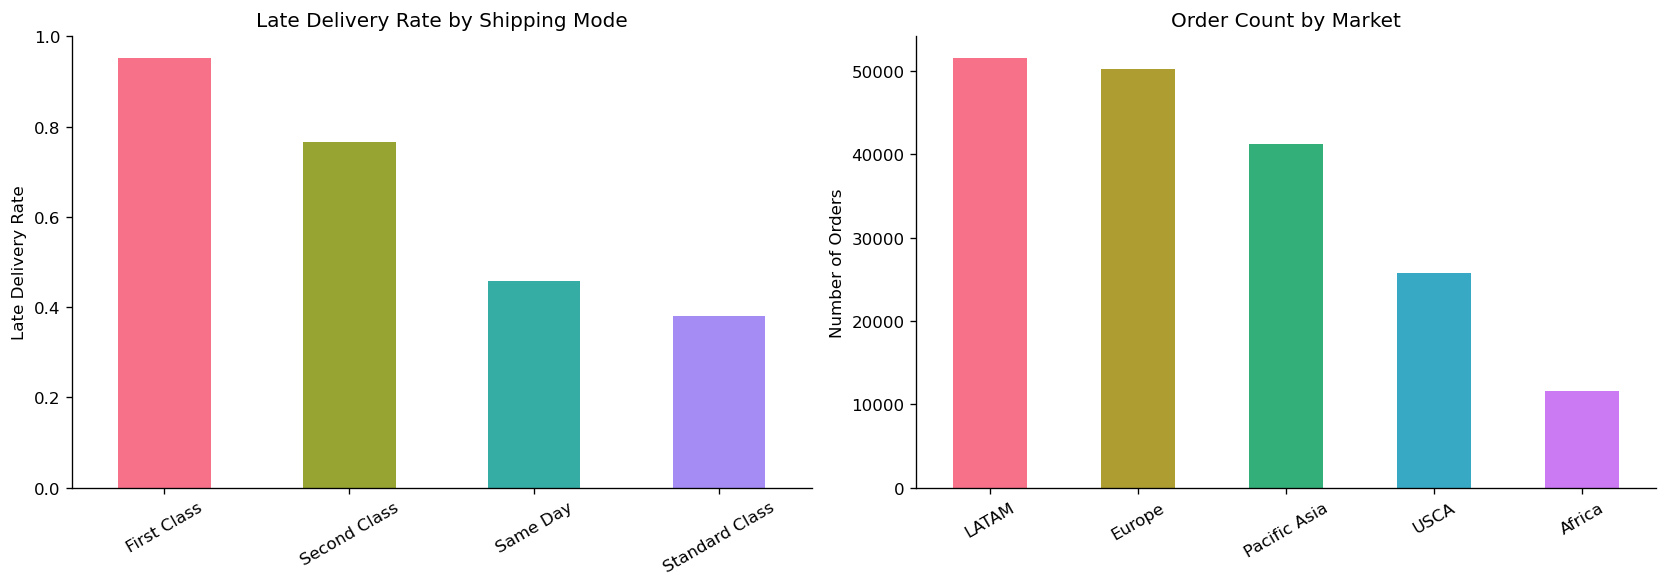

In [16]:
# Late delivery rate by Shipping Mode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

late_by_mode = df.groupby('Shipping Mode')[CLF_TARGET].mean().sort_values(ascending=False)
late_by_mode.plot(kind='bar', ax=axes[0], color=sns.color_palette(PALETTE, len(late_by_mode)))
axes[0].set_title('Late Delivery Rate by Shipping Mode')
axes[0].set_ylabel('Late Delivery Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Order count by market
market_counts = df['Market'].value_counts()
market_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette(PALETTE, len(market_counts)))
axes[1].set_title('Order Count by Market')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

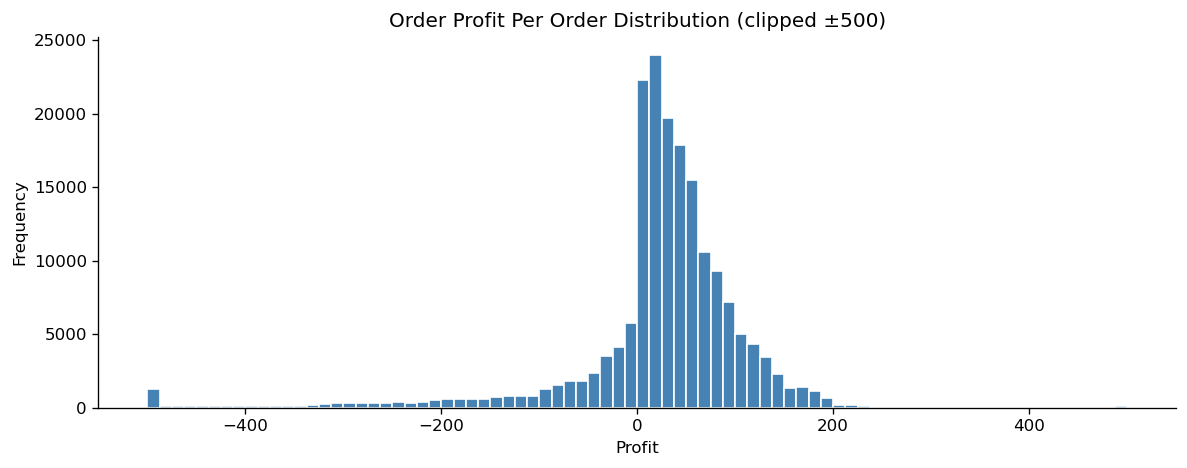

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Order Profit Per Order, dtype: float64


In [17]:
# ── Order Profit Per Order distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
df[REG_TARGET].clip(-500, 500).plot(kind='hist', bins=80, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Order Profit Per Order Distribution (clipped ±500)')
ax.set_xlabel('Profit')
plt.tight_layout()
plt.show()

print(df[REG_TARGET].describe())

# Data Cleaning

In [18]:
# Convert Dates
date_cols = [
    'order date (DateOrders)',
    'shipping date (DateOrders)'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create Date Features

In [19]:
df['order_year'] = df['order date (DateOrders)'].dt.year
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day

df.head()

,Type,Days for shipment (scheduled),Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,...,Shipping Mode,order_year,order_month,order_day,order_date,order_dayofweek,order_hour,order_quarter,discount_rate,price_band
0,DEBIT,4,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,...,Standard Class,2018,1,31,2018-01-31 22:56:00,2,22,1,0.041667,3
1,TRANSFER,4,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,...,Standard Class,2018,1,13,2018-01-13 12:27:00,5,12,1,0.052640,3
2,CASH,4,0,73,Sporting Goods,San Jose,EE. UU.,Gillian,19491,Maldonado,...,Standard Class,2018,1,13,2018-01-13 12:06:00,5,12,1,0.058214,3
3,DEBIT,4,0,73,Sporting Goods,Los Angeles,EE. UU.,Tana,19490,Tate,...,Standard Class,2018,1,13,2018-01-13 11:45:00,5,11,1,0.075260,3
4,PAYMENT,4,0,73,Sporting Goods,Caguas,Puerto Rico,Orli,19489,Hendricks,...,Standard Class,2018,1,13,2018-01-13 11:24:00,5,11,1,0.098910,3


# Encoding

In [20]:
# Label Encoding
cat_cols = df_model.select_dtypes(include='object').columns
encoder = LabelEncoder()

for col in cat_cols:
    df_model[col] = encoder.fit_transform(
        df_model[col].astype(str)
    )
df_model.head()

NameError: name 'df_model' is not defined

In [ ]:
# Missing Value Treatment
imputer = SimpleImputer(strategy="median")

df_model[df_model.columns] = imputer.fit_transform(df_model)

## 5. Feature Engineering

In [ ]:
# Parse order date for temporal features
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['order_month']     = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek   # Mon=0, Sun=6
df['order_hour']      = df['order_date'].dt.hour
df['order_quarter']   = df['order_date'].dt.quarter

# ── Scheduled shipping duration (known at order time) ────────────────────
# 'Days for shipment (scheduled)' is the PROMISED days — available pre-delivery
# This is SAFE to use (unlike 'Days for shipping (real)' which is the actual)

# ── Discount amount ───────────────────────────────────────────────────────
if 'Order Item Discount' in df.columns and 'Order Item Total' in df.columns:
    df['discount_rate'] = df['Order Item Discount'] / (df['Order Item Total'] + 1e-9)

# ── Product price band (ordinal encoding) ────────────────────────────────
if 'Product Price' in df.columns:
    df['price_band'] = pd.qcut(df['Product Price'], q=4, labels=False, duplicates='drop')

print("New engineered features added ✅")
print(df[['order_month', 'order_dayofweek', 'order_hour', 'order_quarter']].head())

## 6. Preprocessing Pipeline

In [ ]:
# Select features
EXCLUDE = [
    CLF_TARGET, REG_TARGET,
    'order date (DateOrders)', 'shipping date (DateOrders)', 'order_date',
    'Customer Fname', 'Customer Lname', 'Customer Street',  # PII
    'Product Name',   # too high cardinality without embedding
]

feature_cols = [c for c in df.columns if c not in EXCLUDE]
print(f"Total feature columns: {len(feature_cols)}")

#Split numeric vs categorical
num_cols = df[feature_cols].select_dtypes(include=['number']).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

# Label-encode categoricals (for tree models)
df_enc = df[feature_cols + [CLF_TARGET, REG_TARGET]].copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = df_enc[col].astype(str).fillna('MISSING')
    df_enc[col] = le.fit_transform(df_enc[col])

df_enc[num_cols] = df_enc[num_cols].fillna(df_enc[num_cols].median())

print("Encoding complete ✅")
print(df_enc.shape)

In [ ]:
# Train / Test split
X = df_enc[feature_cols]
yc = df_enc[CLF_TARGET]      # classification target
yr = df_enc[REG_TARGET]      # regression target

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, yc, yr, test_size=0.2, random_state=42, stratify=yc
)

# Scaled version for Logistic Regression
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train): {yc_train.value_counts(normalize=True).to_dict()}")

# Classification Dataset

In [ ]:
y = df[CLF_TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling

In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)

## Classification — Late Delivery Risk

In [ ]:
def eval_clf(name, model, X_tr, X_te, y_tr, y_te):

    # Train
    model.fit(X_tr, y_tr)

    # Prediction
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average="weighted")

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_prob)
    else:
        auc = np.nan

    # Store results
    clf_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 (weighted)': f1,
        'ROC-AUC': auc
    })

    model_map[name] = model

    print(f"{name:<30} Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    return model

In [ ]:
# ── Logistic Regression (baseline — uses scaled data) ────────────────────
lr = eval_clf(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, X_test_sc, yc_train, yc_test
)

In [ ]:
# Decision Tree
dt = eval_clf(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8, random_state=42),
    X_train, X_test, yc_train, yc_test
)

In [ ]:
# Random Forest
rf = eval_clf(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    X_train, X_test, yc_train, yc_test
)

In [ ]:
# XGBoost
xgb_clf = eval_clf(
    "XGBoost",
    xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    X_train, X_test, yc_train, yc_test
)

In [ ]:
# LightGBM
lgb_clf = eval_clf(
    "LightGBM",
    lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    X_train, X_test, yc_train, yc_test
)

In [ ]:
# ── Voting Ensemble (soft voting) ─────────────────────────────────────────
vote_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                               eval_metric='logloss', random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                random_state=42, n_jobs=-1, verbose=-1)),
]
voting_clf = eval_clf(
    "Voting Ensemble",
    VotingClassifier(estimators=vote_estimators, voting='soft', n_jobs=-1),
    X_train, X_test, yc_train, yc_test
)

In [ ]:
# ── Classification results table ──────────────────────────────────────────
clf_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n📊 Classification Model Comparison")
print(clf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
clf_df_plot = clf_df.set_index('Model')[['Accuracy', 'F1 (weighted)', 'ROC-AUC']]
clf_df_plot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Classification Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, label='Perfect = leakage risk')
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

In [ ]:
# Create classifier results dataframe
clf_df = pd.DataFrame(clf_results)

# Sort best model by Accuracy
clf_df = clf_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(clf_df)

In [ ]:
# Confusion matrix for best classifier

best_clf_name = clf_df.iloc[0]['Model']
best_clf = model_map[best_clf_name]

if best_clf_name == 'Logistic Regression':
    X_eval = X_test_sc
else:
    X_eval = X_test

y_pred = best_clf.predict(X_eval)

cm = confusion_matrix(yc_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_clf_name}")

plt.show()

## 8. Regression

In [ ]:
# Regression feature set: same X_train / X_test but drop clf target
reg_results = []

def eval_reg(name, model, X_tr, X_te, y_tr, y_te):
    """Fit, predict, and record regression metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    reg_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"{name:<30} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    return model

print("=" * 65)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 65)

In [ ]:
# Linear models (use scaled data)
for name, model in [
    ('Linear Regression', LinearRegression()),
    ('Ridge',             Ridge(alpha=1.0)),
    ('Lasso',             Lasso(alpha=0.1, max_iter=5000)),
    ('ElasticNet',        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
]:
    eval_reg(name, model, X_train_sc, X_test_sc, yr_train, yr_test)

## 9. Feature Importance

In [ ]:
# Feature importance from best tree classifier
# Use Random Forest or XGBoost (whichever is in model_map)
for imp_model_name in ['LightGBM', 'XGBoost', 'Random Forest']:
    if imp_model_name in model_map:
        imp_model = model_map[imp_model_name]
        break

if hasattr(imp_model, 'feature_importances_'):
    feat_imp = pd.Series(imp_model.feature_importances_, index=X_train.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'Top 20 Feature Importances — {imp_model_name} (Classification)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("No feature_importances_ available for this model.")

# Save Processed Dataset

In [ ]:
df.to_csv('Processed_DataCoSupplyChainDataset.csv', index=False)

print('Processed.dataset saved successfully!')

# Conclusion

In [ ]:
print('DataCoSupplyChainDataset Tracking System analysis completed successfully!')